# Week 7 — stability and drift (Wednesday, 1 hour)

Six exercises on fc-10's `drift` module and Decision 5. The drift is a **stated scenario**, not an observation, and
every rate is **PLANTED TRUTH**. Read `README.md` in this folder first.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
drift = fc10_module("runtime.manufacturing.tuning.drift")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")
sns.set_theme(style="whitegrid")

[d5] = [e for e in decision_log.load() if e["decision_id"] == "D5"]
ev = d5["evidence"]
periods = drift.periods(d5["assumptions"]["scenario"])
for p, _pop in periods:
    print(p["label"], "seed", p["seed"], "· inflation x", p["all"], "· step", p["step"])

Y1 seed 20260924 · inflation x 1.0 · step None
Y2 seed 20260926 · inflation x 1.1 · step {'factor': 1.6, 'from_month': 6, 'segments': ['business', 'corporate', 'correspondent']}
Y3 seed 20260927 · inflation x 1.21 · step {'factor': 1.6, 'from_month': 0, 'segments': ['business', 'corporate', 'correspondent']}


## Exercise 1 — the rules, held fixed, over three years

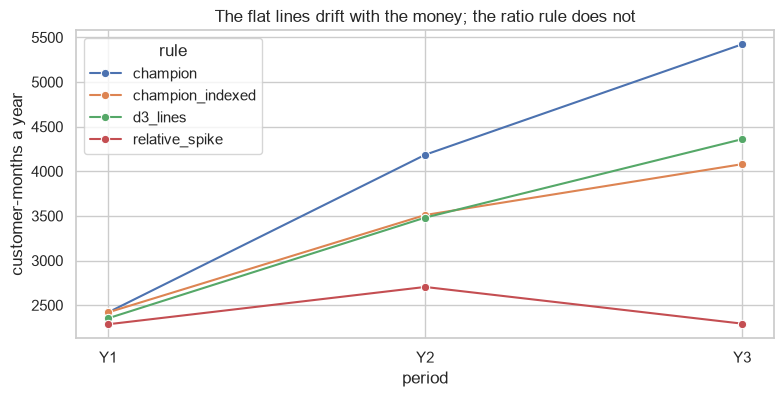

,verdict,Y2,Y3
champion,UNSTABLE,0.7301,1.2418
champion_indexed,UNSTABLE,0.451,0.6866
d3_lines,UNSTABLE,0.4794,0.853
relative_spike,STABLE,0.1829,0.0031


In [2]:
rows = []
for name, r in ev["rules"].items():
    for label, s in r["periods"].items():
        rows.append({"rule": name, "period": label, "workload": s["workload"], "caught": s["tp"]})
w = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(w, x="period", y="workload", hue="rule", marker="o", ax=ax)
ax.set(ylabel="customer-months a year", title="The flat lines drift with the money; the ratio rule does not")
plt.show()
pd.DataFrame({n: {"verdict": d5["stability_findings"][n], **{l: c["workload_change"] for l, c in r["changes"].items()}}
              for n, r in ev["rules"].items()}).T

## Exercise 2 — KS and PSI, by hand and by scipy

fc-10 computes both itself. Check its KS against scipy's, then read what they say about the payment amounts.

In [3]:
base = [t.amount for t in periods[0][1].transactions]
for p, pop in periods[1:]:
    amt = [t.amount for t in pop.transactions]
    fd = ev["feature_drift"][p["label"]]["payment_amount"]
    print(p["label"], "KS fc-10", fd["ks"], "scipy", round(ks_2samp(base, amt).statistic, 6), "· PSI", fd["psi"], fd["psi_band"])

Y2 KS fc-10 0.050785 scipy 0.050785 · PSI 0.019776 stable
Y3 KS fc-10 0.082586 scipy 0.082586 · PSI 0.052304 stable


## Exercise 3 — why the drift statistics say "stable"

The whole distribution barely moves. Look at it on a log scale, year against year.

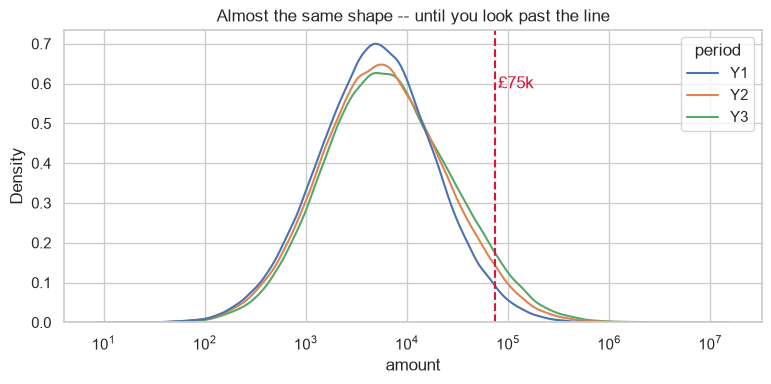

In [4]:
frame = pd.concat([pd.DataFrame({"amount": [t.amount for t in pop.transactions], "period": p["label"]}) for p, pop in periods])
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.kdeplot(frame, x="amount", hue="period", log_scale=True, common_norm=False, ax=ax)
ax.axvline(75_000, ls="--", c="crimson"); ax.text(80_000, ax.get_ylim()[1] * 0.8, "£75k", color="crimson")
ax.set(title="Almost the same shape -- until you look past the line")
plt.show()

## Exercise 4 — PSI of the whole, against the change in the tail

The rule works on the customer-months above £75k. Compare the PSI with how much that tail share changed.

In [5]:
def tail_share(pop, line=75_000):
    top = {}
    for t in pop.transactions:
        k = (t.customer_id, t.value_date[:7]); top[k] = max(top.get(k, 0), t.amount)
    return sum(v > line for v in top.values()) / len(top)
t0 = tail_share(periods[0][1])
pd.DataFrame([{"period": p["label"], "PSI payment amounts": ev["feature_drift"].get(p["label"], {}).get("payment_amount", {}).get("psi", 0.0),
               "share of customer-months above £75k": round(tail_share(pop), 4),
               "tail change vs Y1": f"{tail_share(pop) / t0 - 1:+.0%}"} for p, pop in periods])

,period,PSI payment amounts,share of customer-months above £75k,tail change vs Y1
0,Y1,0.000000,0.0424,+0%
1,Y2,0.019776,0.0733,+73%
2,Y3,0.052304,0.0951,+124%


PSI stays in the "stable" band while the tail the rule works on grows by double digits. That's why D5 makes each rule's
**own alert volume** the monitoring trigger, and keeps PSI and KS as supporting signals.

## Exercise 5 — the customer-baseline rule's transient

Its annual workload stays within tolerance. Its **monthly** workload in year 2 doesn't stay flat.

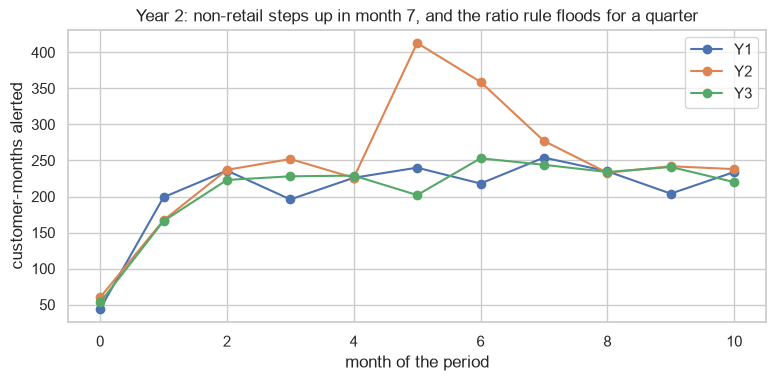

{'Y1': 1.12, 'Y2': 1.74, 'Y3': 1.11}

In [6]:
m = ev["rules"]["relative_spike"]["monthly_workload"]
fig, ax = plt.subplots(figsize=(9, 3.8))
for label, months in m.items():
    ax.plot(list(range(len(months))), list(months.values()), marker="o", label=label)
ax.set(xlabel="month of the period", ylabel="customer-months alerted",
       title="Year 2: non-retail steps up in month 7, and the ratio rule floods for a quarter")
ax.legend(); plt.show()
{l: s["peak_month_ratio"] for l, s in ev["rules"]["relative_spike"]["periods"].items()}

## Exercise 6 — Decision 5, as logged

In [7]:
print(d5["decision"], d5["stability_findings"])
print()
for m in d5["mitigants"]:
    print("-", m)

HOLD {'champion': 'UNSTABLE', 'champion_indexed': 'UNSTABLE', 'd3_lines': 'UNSTABLE', 'relative_spike': 'STABLE'}

- Monitor each rule's OWN monthly alert volume against its first-period level, with the stated tolerances; PSI and KS on payment amounts read stable throughout while the flat rules' workload doubled, so they are not the trigger.
- Recalibrate the flat lines (the champion and D3's two lines) at least annually. Indexing the champion to the median payment was measured and NOT adopted: it only halves the drift, because the drift sits in the tail.
- Make a step-change warm-up part of the customer-baseline rule's week-9 validation: after a segment's business steps up, its monthly workload runs up to 1.74x its median month for about a quarter, the length of its baseline window.


## Your answers (the curriculum's success criteria)

1. **Which thresholds are unstable, and how do you know?** Use Exercise 1.

    *…*

2. **Why would a PSI-based monitor have missed it?** Use Exercises 3 and 4.

    *…*

3. **Propose mitigants: what you'd monitor, how often, and what you'd do when it trips.**

    *…*